# CVaR Portfolio Optimization

This notebook constructs portfolios using Conditional Value-at-Risk (CVaR) as
a downside-risk measure. The strategies are evaluated through the same rolling
three-year estimation window and monthly out-of-sample backtest used for the
GMV and mean–variance portfolios.

In [38]:
from pathlib import Path

import cvxpy as cp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

TRADING_DAYS = 252
ESTIMATION_YEARS = 3
CONFIDENCE_LEVEL = 0.95
TRANSACTION_COST = 0.001

In [39]:
PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "etf_adjusted_close.csv"
)

RESULTS_DIR = PROJECT_ROOT / "results"

print("Project root:", PROJECT_ROOT)
print("Data path:", DATA_PATH)
print("Results directory:", RESULTS_DIR)

Project root: /Users/yyi/Projects/Portfolio optimization
Data path: /Users/yyi/Projects/Portfolio optimization/data/processed/etf_adjusted_close.csv
Results directory: /Users/yyi/Projects/Portfolio optimization/results


In [40]:
prices = pd.read_csv(
    DATA_PATH,
    index_col="Date",
    parse_dates=["Date"],
)

prices = prices.sort_index()

returns = (
    prices
    .pct_change(fill_method=None)
    .dropna()
)

print("Prices shape:", prices.shape)
print("Returns shape:", returns.shape)
print(
    "Full date range:",
    returns.index.min(),
    "to",
    returns.index.max(),
)

Prices shape: (3268, 12)
Returns shape: (3267, 12)
Full date range: 2007-04-12 00:00:00 to 2020-04-01 00:00:00


In [41]:
backtest_start = returns.index[
    returns.index
    >= returns.index.min()
    + pd.DateOffset(years=ESTIMATION_YEARS)
][0]

backtest_end = returns.index.max()

backtest_returns = returns.loc[
    backtest_start:backtest_end
]

formation_dates = (
    backtest_returns
    .groupby(
        backtest_returns.index.to_period("M")
    )
    .head(1)
    .index
)

print(
    "Backtest period:",
    backtest_start,
    "to",
    backtest_end,
)

print("Number of formation dates:", len(formation_dates))
print("First formation date:", formation_dates[0])
print("Last formation date:", formation_dates[-1])

Backtest period: 2010-04-12 00:00:00 to 2020-04-01 00:00:00
Number of formation dates: 121
First formation date: 2010-04-12 00:00:00
Last formation date: 2020-04-01 00:00:00


In [42]:
gmv_returns = (
    pd.read_csv(
        RESULTS_DIR / "gmv_daily_returns.csv",
        index_col=0,
        parse_dates=[0],
    )
    .iloc[:, 0]
    .rename("GMV")
)

mean_variance_returns = pd.read_csv(
    RESULTS_DIR / "mean_variance_daily_returns.csv",
    index_col=0,
    parse_dates=[0],
)

print("GMV returns shape:", gmv_returns.shape)
print(
    "Mean–variance returns shape:",
    mean_variance_returns.shape,
)

print(
    "GMV date range:",
    gmv_returns.index.min(),
    "to",
    gmv_returns.index.max(),
)

GMV returns shape: (2512,)
Mean–variance returns shape: (2512, 7)
GMV date range: 2010-04-12 00:00:00 to 2020-04-01 00:00:00


In [43]:
assert prices.index.is_monotonic_increasing
assert returns.index.is_monotonic_increasing
assert formation_dates[0] == backtest_start
assert not returns.isna().any().any()

display(prices.head())
display(returns.head())

,SPY,QQQ,IWM,EFA,EEM,IEF,TLT,LQD,HYG,GLD,DBC,VNQ
Date,,,,,,,,,,,,
2007-04-11,110.289658,39.279694,66.941124,52.894066,30.795134,59.255993,58.066200,62.582520,44.114380,67.080002,23.717676,45.059521
2007-04-12,110.779778,39.590656,67.391281,53.247246,31.310007,59.313496,58.079468,62.676716,44.143967,66.989998,23.857685,44.752880
2007-04-13,111.285194,39.670624,67.824745,53.423836,31.463705,59.212826,57.900051,62.570763,44.063625,67.839996,23.988363,45.258251
2007-04-16,112.341995,40.034893,68.758461,53.987541,31.837688,59.277557,58.219078,62.623730,44.046719,68.400002,23.801685,45.315048
2007-04-17,112.640648,40.123745,68.550041,53.994328,31.666058,59.529251,58.544727,62.965149,44.025558,68.000000,23.559000,45.905624


,SPY,QQQ,IWM,EFA,EEM,IEF,TLT,LQD,HYG,GLD,DBC,VNQ
Date,,,,,,,,,,,,
2007-04-12,0.004444,0.007917,0.006725,0.006677,0.016719,0.000970,0.000228,0.001505,0.000671,-0.001342,0.005903,-0.006805
2007-04-13,0.004562,0.002020,0.006432,0.003316,0.004909,-0.001697,-0.003089,-0.001690,-0.001820,0.012688,0.005477,0.011292
2007-04-16,0.009496,0.009182,0.013767,0.010552,0.011886,0.001093,0.005510,0.000847,-0.000384,0.008255,-0.007782,0.001255
2007-04-17,0.002658,0.002219,-0.003031,0.000126,-0.005391,0.004246,0.005594,0.005452,-0.000480,-0.005848,-0.010196,0.013033
2007-04-18,0.001224,-0.003322,-0.005837,-0.000377,-0.007442,0.002295,0.004995,0.000280,0.000288,0.005588,0.000396,-0.006185


## Single-Period Minimum-CVaR Portfolio

For a portfolio with weight vector $w$, the loss under historical return scenario
$t$ is

$$
L_t(w)=-r_t^\top w.
$$

At confidence level $\beta=0.95$, Value-at-Risk (VaR) represents the loss
threshold associated with the worst 5% of observations. Conditional
Value-at-Risk (CVaR) measures the average loss in this upper tail.

The empirical CVaR optimization problem can be written as

$$
\begin{aligned}
\min_{w,\eta,u}\quad
&\eta+\frac{1}{(1-\beta)T}\sum_{t=1}^T u_t\\
\text{subject to}\quad
&u_t\geq L_t(w)-\eta,\\
&u_t\geq0,\\
&\mathbf 1^\top w=1,\\
&w\geq0,
\end{aligned}
$$

where $\eta$ represents the portfolio VaR threshold and $u_t$ represents the
loss exceeding that threshold in scenario $t$. Unlike variance, CVaR focuses
specifically on unfavorable tail outcomes.


In [44]:
formation_date = formation_dates[0]

estimation_start = (
    formation_date
    - pd.DateOffset(years=ESTIMATION_YEARS)
)

estimation_returns = returns.loc[
    (returns.index >= estimation_start)
    & (returns.index < formation_date)
]

print("Formation date:", formation_date)
print(
    "Estimation period:",
    estimation_returns.index.min(),
    "to",
    estimation_returns.index.max(),
)
print("Number of scenarios:", len(estimation_returns))
print(
    "Approximate tail observations:",
    len(estimation_returns)
    * (1 - CONFIDENCE_LEVEL),
)

Formation date: 2010-04-12 00:00:00
Estimation period: 2007-04-12 00:00:00 to 2010-04-09 00:00:00
Number of scenarios: 755
Approximate tail observations: 37.750000000000036


In [45]:
def solve_minimum_cvar(
    estimation_returns,
    confidence_level=0.95,
):
    scenario_returns = (
        estimation_returns
        .to_numpy(dtype=float)
    )

    number_of_scenarios, number_of_assets = (
        scenario_returns.shape
    )

    weights = cp.Variable(
        number_of_assets,
        name="weights",
    )

    var_threshold = cp.Variable(
        name="var_threshold",
    )

    excess_losses = cp.Variable(
        number_of_scenarios,
        nonneg=True,
        name="excess_losses",
    )

    portfolio_losses = (
        -scenario_returns @ weights
    )

    portfolio_cvar = (
        var_threshold
        + cp.sum(excess_losses)
        / (
            (1 - confidence_level)
            * number_of_scenarios
        )
    )

    constraints = [
        cp.sum(weights) == 1,
        weights >= 0,
        excess_losses
        >= portfolio_losses - var_threshold,
    ]

    problem = cp.Problem(
        cp.Minimize(portfolio_cvar),
        constraints,
    )

    problem.solve(solver="CLARABEL")

    if problem.status not in [
        "optimal",
        "optimal_inaccurate",
    ]:
        raise ValueError(
            f"Optimization failed: {problem.status}"
        )

    optimized_weights = pd.Series(
        weights.value,
        index=estimation_returns.columns,
        name="minimum_cvar_weight",
    )

    optimized_weights = optimized_weights.clip(
        lower=0
    )

    optimized_weights /= optimized_weights.sum()

    return {
        "weights": optimized_weights,
        "status": problem.status,
        "daily_var": float(var_threshold.value),
        "daily_cvar": float(problem.value),
    }

In [46]:
initial_cvar_solution = solve_minimum_cvar(
    estimation_returns,
    confidence_level=CONFIDENCE_LEVEL,
)

minimum_cvar_weights = (
    initial_cvar_solution["weights"]
)

print(
    "Status:",
    initial_cvar_solution["status"],
)

print(
    "Estimated daily 95% VaR:",
    initial_cvar_solution["daily_var"],
)

print(
    "Estimated daily 95% CVaR:",
    initial_cvar_solution["daily_cvar"],
)

print("\nMinimum-CVaR weights:")

display(
    minimum_cvar_weights
    .sort_values(ascending=False)
    .to_frame()
    .style
    .format("{:.2%}")
)

assert np.isclose(
    minimum_cvar_weights.sum(),
    1,
)

assert (
    minimum_cvar_weights >= 0
).all()

Status: optimal
Estimated daily 95% VaR: 0.0060561889125439325
Estimated daily 95% CVaR: 0.008327662954046355

Minimum-CVaR weights:


,minimum_cvar_weight
IEF,70.80%
HYG,9.73%
QQQ,8.04%
GLD,7.70%
DBC,3.18%
LQD,0.55%
IWM,0.00%
SPY,0.00%
TLT,0.00%
EEM,0.00%


In [47]:
minimum_cvar_weights_history = pd.DataFrame(
    index=formation_dates,
    columns=returns.columns,
    dtype=float,
)

minimum_cvar_risk_estimates = pd.DataFrame(
    index=formation_dates,
    columns=[
        "Estimated Daily VaR",
        "Estimated Daily CVaR",
    ],
    dtype=float,
)

solver_status = {}

for formation_date in formation_dates:
    estimation_start = (
        formation_date
        - pd.DateOffset(years=ESTIMATION_YEARS)
    )

    estimation_returns = returns.loc[
        (returns.index >= estimation_start)
        & (returns.index < formation_date)
    ]

    solution = solve_minimum_cvar(
        estimation_returns,
        confidence_level=CONFIDENCE_LEVEL,
    )

    minimum_cvar_weights_history.loc[
        formation_date
    ] = solution["weights"]

    minimum_cvar_risk_estimates.loc[
        formation_date,
        "Estimated Daily VaR",
    ] = solution["daily_var"]

    minimum_cvar_risk_estimates.loc[
        formation_date,
        "Estimated Daily CVaR",
    ] = solution["daily_cvar"]

    solver_status[formation_date] = (
        solution["status"]
    )

In [48]:
assert not minimum_cvar_weights_history.isna().any().any()

assert np.allclose(
    minimum_cvar_weights_history.sum(axis=1),
    1,
)

assert (
    minimum_cvar_weights_history >= -1e-8
).all().all()

assert (
    minimum_cvar_risk_estimates[
        "Estimated Daily CVaR"
    ]
    >= minimum_cvar_risk_estimates[
        "Estimated Daily VaR"
    ] - 1e-8
).all()

assert all(
    status in [
        "optimal",
        "optimal_inaccurate",
    ]
    for status in solver_status.values()
)

print(
    "Number of portfolios solved:",
    len(minimum_cvar_weights_history),
)

display(
    minimum_cvar_weights_history.head()
)

display(
    minimum_cvar_risk_estimates.head()
)

Number of portfolios solved: 121


,SPY,QQQ,IWM,EFA,EEM,IEF,TLT,LQD,HYG,GLD,DBC,VNQ
Date,,,,,,,,,,,,
2010-04-12,3.761791e-12,0.080377,9.073575e-12,7.629364e-13,1.303055e-12,0.707986,2.665828e-12,0.005478,0.097342,0.076972,0.031845,1.189378e-12
2010-05-03,6.846716e-12,0.080377,1.651094e-11,1.388579e-12,2.369782e-12,0.707986,4.848746e-12,0.005478,0.097342,0.076972,0.031845,2.164828e-12
2010-06-01,2.539772e-12,0.080377,6.360370e-12,5.455992e-13,9.247093e-13,0.707986,1.849178e-12,0.005478,0.097342,0.076972,0.031845,9.146518e-13
2010-07-01,2.395172e-12,0.091381,7.291176e-12,5.423347e-13,6.653315e-13,0.711124,1.740610e-12,0.011189,0.083633,0.078890,0.023784,1.282246e-12
2010-08-02,3.608370e-11,0.092500,1.018675e-10,7.379598e-12,1.024851e-11,0.709910,2.536062e-11,0.011236,0.085034,0.080159,0.021161,1.648521e-11


,Estimated Daily VaR,Estimated Daily CVaR
Date,,
2010-04-12,0.006056,0.008328
2010-05-03,0.006056,0.008328
2010-06-01,0.006056,0.008328
2010-07-01,0.006025,0.008193
2010-08-02,0.006060,0.008196


In [49]:
def backtest_monthly_weights(
    returns,
    weights_history,
    backtest_end,
):
    realized_return_segments = []

    formation_dates = weights_history.index

    for i, formation_date in enumerate(
        formation_dates
    ):
        initial_weights = (
            weights_history
            .loc[formation_date]
            .astype(float)
        )

        if i < len(formation_dates) - 1:
            next_formation_date = (
                formation_dates[i + 1]
            )

            holding_returns = returns.loc[
                (returns.index >= formation_date)
                & (
                    returns.index
                    < next_formation_date
                )
            ]

        else:
            holding_returns = returns.loc[
                (returns.index >= formation_date)
                & (returns.index <= backtest_end)
            ]

        asset_growth = (
            1 + holding_returns
        ).cumprod()

        portfolio_wealth = (
            asset_growth
            .mul(
                initial_weights,
                axis="columns",
            )
            .sum(axis=1)
        )

        portfolio_returns = (
            portfolio_wealth.pct_change()
        )

        portfolio_returns.iloc[0] = (
            portfolio_wealth.iloc[0] - 1
        )

        realized_return_segments.append(
            portfolio_returns
        )

    portfolio_returns = pd.concat(
        realized_return_segments
    )

    return portfolio_returns

In [50]:
minimum_cvar_returns = (
    backtest_monthly_weights(
        returns=returns,
        weights_history=(
            minimum_cvar_weights_history
        ),
        backtest_end=backtest_end,
    )
)

minimum_cvar_returns.name = "Minimum_CVaR"

In [51]:
assert not minimum_cvar_returns.isna().any()

assert not minimum_cvar_returns.index.duplicated().any()

assert minimum_cvar_returns.index.equals(
    backtest_returns.index
)

print(
    "Date range:",
    minimum_cvar_returns.index.min(),
    "to",
    minimum_cvar_returns.index.max(),
)

print(
    "Number of realized returns:",
    len(minimum_cvar_returns),
)

display(minimum_cvar_returns.head())

Date range: 2010-04-12 00:00:00 to 2020-04-01 00:00:00
Number of realized returns: 2512


Date
2010-04-12    0.001558
2010-04-13    0.001943
2010-04-14   -0.000083
2010-04-15    0.002357
2010-04-16    0.000304
Name: Minimum_CVaR, dtype: float64

In [52]:
def calculate_performance_metrics(
    daily_returns,
    confidence_level=0.95,
):
    daily_returns = daily_returns.dropna()

    wealth = (
        1 + daily_returns
    ).cumprod()

    final_wealth = wealth.iloc[-1]

    number_of_years = (
        len(daily_returns) / TRADING_DAYS
    )

    cagr = (
        final_wealth
        ** (1 / number_of_years)
        - 1
    )

    annualized_volatility = (
        daily_returns.std()
        * np.sqrt(TRADING_DAYS)
    )

    annualized_mean_return = (
        daily_returns.mean()
        * TRADING_DAYS
    )

    sharpe_ratio = (
        annualized_mean_return
        / annualized_volatility
    )

    running_maximum = wealth.cummax()

    drawdown = (
        wealth / running_maximum - 1
    )

    maximum_drawdown = drawdown.min()

    realized_losses = -daily_returns

    daily_var = np.quantile(
        realized_losses,
        confidence_level,
    )

    daily_cvar = realized_losses.loc[
        realized_losses >= daily_var
    ].mean()

    return {
        "Final Wealth": final_wealth,
        "CAGR": cagr,
        "Annualized Volatility":
            annualized_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Maximum Drawdown": maximum_drawdown,
        "Daily 95% VaR": daily_var,
        "Daily 95% CVaR": daily_cvar,
    }

In [53]:
spy_returns = returns.loc[
    minimum_cvar_returns.index,
    "SPY",
].rename("SPY")

qqq_returns = returns.loc[
    minimum_cvar_returns.index,
    "QQQ",
].rename("QQQ")

comparison_returns = pd.concat(
    [
        gmv_returns.rename("GMV"),
        spy_returns,
        qqq_returns,
        mean_variance_returns,
        minimum_cvar_returns,
    ],
    axis=1,
).dropna()

In [54]:
performance_table = pd.DataFrame({
    strategy: calculate_performance_metrics(
        comparison_returns[strategy],
        confidence_level=CONFIDENCE_LEVEL,
    )
    for strategy in comparison_returns.columns
}).T

In [55]:
display(
    performance_table.style.format({
        "Final Wealth": "{:.3f}",
        "CAGR": "{:.2%}",
        "Annualized Volatility": "{:.2%}",
        "Sharpe Ratio": "{:.3f}",
        "Maximum Drawdown": "{:.2%}",
        "Daily 95% VaR": "{:.2%}",
        "Daily 95% CVaR": "{:.2%}",
    })
)

,Final Wealth,CAGR,Annualized Volatility,Sharpe Ratio,Maximum Drawdown,Daily 95% VaR,Daily 95% CVaR
GMV,1.635,5.06%,4.33%,1.162,-9.82%,0.38%,0.63%
SPY,2.519,9.71%,16.95%,0.632,-33.72%,1.62%,2.66%
QQQ,4.133,15.30%,19.19%,0.838,-28.56%,1.92%,2.96%
MV_gamma_1,4.083,15.16%,16.80%,0.925,-25.12%,1.69%,2.68%
MV_gamma_2,3.194,12.36%,14.65%,0.869,-21.01%,1.51%,2.39%
MV_gamma_5,2.506,9.66%,10.40%,0.938,-15.84%,1.05%,1.65%
MV_gamma_10,2.172,8.09%,7.76%,1.041,-14.17%,0.75%,1.18%
MV_gamma_20,1.862,6.43%,5.49%,1.162,-10.73%,0.51%,0.82%
MV_gamma_50,1.769,5.89%,4.45%,1.309,-8.41%,0.40%,0.65%
MV_gamma_100,1.728,5.64%,4.37%,1.279,-9.47%,0.39%,0.64%


## Mean–CVaR Optimization

The pure minimum-CVaR portfolio focuses exclusively on tail-risk reduction and
may sacrifice excessive expected return. A mean–CVaR objective instead balances
estimated return against expected loss in the worst 5% of historical scenarios:

$$
\max_w
\left\{
\hat{\mu}^{\top}w
-
\lambda\operatorname{CVaR}_{0.95}(-Rw)
\right\}.
$$

The parameter $\lambda$ controls aversion to tail risk. A smaller value places
greater emphasis on expected return, while a larger value increasingly favors
tail-risk reduction.

In [73]:
CVAR_PENALTY_VALUES = [
    0.005,
    0.01,
    0.03,
    0.05,
    0.1,
    0.5,
]

In [74]:
def solve_mean_cvar(
    estimation_returns,
    cvar_penalty,
    confidence_level=0.95,
):
    scenario_returns = (
        estimation_returns
        .to_numpy(dtype=float)
    )

    number_of_scenarios, number_of_assets = (
        scenario_returns.shape
    )

    expected_daily_returns = (
        scenario_returns.mean(axis=0)
    )

    weights = cp.Variable(
        number_of_assets,
        name="weights",
    )

    var_threshold = cp.Variable(
        name="var_threshold",
    )

    excess_losses = cp.Variable(
        number_of_scenarios,
        nonneg=True,
        name="excess_losses",
    )

    portfolio_losses = (
        -scenario_returns @ weights
    )

    portfolio_cvar = (
        var_threshold
        + cp.sum(excess_losses)
        / (
            (1 - confidence_level)
            * number_of_scenarios
        )
    )

    portfolio_expected_return = (
        expected_daily_returns @ weights
    )

    objective = cp.Maximize(
        portfolio_expected_return
        - cvar_penalty * portfolio_cvar
    )

    constraints = [
        cp.sum(weights) == 1,
        weights >= 0,
        excess_losses
        >= portfolio_losses - var_threshold,
    ]

    problem = cp.Problem(
        objective,
        constraints,
    )

    problem.solve(solver="CLARABEL")

    if problem.status not in [
        "optimal",
        "optimal_inaccurate",
    ]:
        raise ValueError(
            f"Optimization failed: {problem.status}"
        )

    optimized_weights = pd.Series(
        weights.value,
        index=estimation_returns.columns,
        name=f"mean_cvar_lambda_{cvar_penalty}",
    )

    optimized_weights = optimized_weights.clip(
        lower=0
    )

    optimized_weights /= optimized_weights.sum()

    estimated_daily_return = (
        estimation_returns.mean()
        @ optimized_weights
    )

    return {
        "weights": optimized_weights,
        "status": problem.status,
        "estimated_daily_return":
            float(estimated_daily_return),
        "daily_var":
            float(var_threshold.value),
        "daily_cvar":
            float(portfolio_cvar.value),
        "objective_value":
            float(problem.value),
    }

In [75]:
mean_cvar_initial_weights = pd.DataFrame(
    index=CVAR_PENALTY_VALUES,
    columns=estimation_returns.columns,
    dtype=float,
)

mean_cvar_initial_results = []

for cvar_penalty in CVAR_PENALTY_VALUES:
    solution = solve_mean_cvar(
        estimation_returns,
        cvar_penalty=cvar_penalty,
        confidence_level=CONFIDENCE_LEVEL,
    )

    mean_cvar_initial_weights.loc[
        cvar_penalty
    ] = solution["weights"]

    mean_cvar_initial_results.append({
        "Lambda": cvar_penalty,
        "Estimated Daily Return":
            solution["estimated_daily_return"],
        "Estimated Daily VaR":
            solution["daily_var"],
        "Estimated Daily CVaR":
            solution["daily_cvar"],
        "Objective Value":
            solution["objective_value"],
    })

mean_cvar_initial_results = (
    pd.DataFrame(mean_cvar_initial_results)
    .set_index("Lambda")
)

display(
    mean_cvar_initial_results.style.format({
        "Estimated Daily Return": "{:.4%}",
        "Estimated Daily VaR": "{:.4%}",
        "Estimated Daily CVaR": "{:.4%}",
        "Objective Value": "{:.6f}",
    })
)

,Estimated Daily Return,Estimated Daily VaR,Estimated Daily CVaR,Objective Value
Lambda,,,,
0.005000,0.0582%,0.9504%,1.4118%,0.000512
0.010000,0.0580%,0.9097%,1.3862%,0.000442
0.030000,0.0571%,0.8934%,1.3454%,0.000167
0.050000,0.0333%,0.4292%,0.6409%,0.000012
0.100000,0.0326%,0.4146%,0.6311%,-0.000305
0.500000,0.0174%,0.3034%,0.5517%,-0.002584


In [76]:
for cvar_penalty in CVAR_PENALTY_VALUES:
    print(f"\nLambda = {cvar_penalty}")

    display(
        mean_cvar_initial_weights
        .loc[cvar_penalty]
        .sort_values(ascending=False)
        .head(5)
        .to_frame("Weight")
        .style
        .format("{:.2%}")
    )


Lambda = 0.005


,Weight
TLT,59.88%
QQQ,40.12%
GLD,0.00%
IEF,0.00%
SPY,0.00%



Lambda = 0.01


,Weight
TLT,62.51%
QQQ,37.49%
GLD,0.00%
IEF,0.00%
SPY,0.00%



Lambda = 0.03


...

,Weight
IEF,81.95%
QQQ,16.52%
GLD,1.53%
HYG,0.00%
TLT,0.00%



Lambda = 0.1


,Weight
IEF,85.19%
QQQ,14.81%
HYG,0.00%
SPY,0.00%
GLD,0.00%



Lambda = 0.5


,Weight
IEF,64.57%
HYG,28.85%
DBC,6.13%
QQQ,0.45%
SPY,0.00%


In [77]:
mean_cvar_weights_history = {}
mean_cvar_estimates_history = {}

for cvar_penalty in CVAR_PENALTY_VALUES:
    weights_history = pd.DataFrame(
        index=formation_dates,
        columns=returns.columns,
        dtype=float,
    )

    estimates_history = pd.DataFrame(
        index=formation_dates,
        columns=[
            "Estimated Daily Return",
            "Estimated Daily VaR",
            "Estimated Daily CVaR",
        ],
        dtype=float,
    )

    for formation_date in formation_dates:
        estimation_start = (
            formation_date
            - pd.DateOffset(
                years=ESTIMATION_YEARS
            )
        )

        rolling_estimation_returns = returns.loc[
            (
                returns.index
                >= estimation_start
            )
            & (
                returns.index
                < formation_date
            )
        ]

        solution = solve_mean_cvar(
            rolling_estimation_returns,
            cvar_penalty=cvar_penalty,
            confidence_level=CONFIDENCE_LEVEL,
        )

        weights_history.loc[
            formation_date
        ] = solution["weights"]

        estimates_history.loc[
            formation_date
        ] = [
            solution["estimated_daily_return"],
            solution["daily_var"],
            solution["daily_cvar"],
        ]

    mean_cvar_weights_history[
        cvar_penalty
    ] = weights_history

    mean_cvar_estimates_history[
        cvar_penalty
    ] = estimates_history

    print(
        f"Completed lambda = {cvar_penalty}"
    )

Completed lambda = 0.005
Completed lambda = 0.01
Completed lambda = 0.03
Completed lambda = 0.05
Completed lambda = 0.1
Completed lambda = 0.5


In [78]:
for cvar_penalty, weights_history in (
    mean_cvar_weights_history.items()
):
    assert not weights_history.isna().any().any()

    assert np.allclose(
        weights_history.sum(axis=1),
        1,
    )

    assert (
        weights_history >= -1e-8
    ).all().all()

print("All rolling optimizations completed.")

All rolling optimizations completed.


In [79]:
mean_cvar_returns = {}

for cvar_penalty, weights_history in (
    mean_cvar_weights_history.items()
):
    strategy_name = (
        f"Mean_CVaR_lambda_{cvar_penalty:g}"
    )

    mean_cvar_returns[strategy_name] = (
        backtest_monthly_weights(
            returns=returns,
            weights_history=weights_history,
            backtest_end=backtest_end,
        )
    )

mean_cvar_returns = pd.DataFrame(
    mean_cvar_returns
)

assert not mean_cvar_returns.isna().any().any()

display(mean_cvar_returns.head())

,Mean_CVaR_lambda_0.005,Mean_CVaR_lambda_0.01,Mean_CVaR_lambda_0.03,Mean_CVaR_lambda_0.05,Mean_CVaR_lambda_0.1,Mean_CVaR_lambda_0.5
Date,,,,,,
2010-04-12,-0.005544,-0.005739,0.000519,0.001176,0.001373,0.001520
2010-04-13,-0.002832,-0.002771,0.001153,0.001673,0.001824,0.001917
2010-04-14,0.003017,0.003952,0.000152,0.000029,-0.000020,-0.000061
2010-04-15,0.005485,0.004605,0.002536,0.002568,0.002463,0.002391
2010-04-16,-0.021205,-0.021847,-0.002359,-0.000737,-0.000217,0.000213


In [80]:
selected_mean_variance_returns = (
    mean_variance_returns[
        [
            "MV_gamma_5",
            "MV_gamma_50",
        ]
    ]
)

cvar_comparison_returns = pd.concat(
    [
        gmv_returns.rename("GMV"),
        spy_returns,
        qqq_returns,
        selected_mean_variance_returns,
        minimum_cvar_returns,
        mean_cvar_returns,
    ],
    axis=1,
).dropna()

assert not cvar_comparison_returns.isna().any().any()

print(
    "Comparison period:",
    cvar_comparison_returns.index.min(),
    "to",
    cvar_comparison_returns.index.max(),
)

print(
    "Number of daily observations:",
    len(cvar_comparison_returns),
)

Comparison period: 2010-04-12 00:00:00 to 2020-04-01 00:00:00
Number of daily observations: 2512


In [81]:
cvar_performance_table = pd.DataFrame({
    strategy: calculate_performance_metrics(
        cvar_comparison_returns[strategy],
        confidence_level=CONFIDENCE_LEVEL,
    )
    for strategy in cvar_comparison_returns.columns
}).T

display(
    cvar_performance_table.style.format({
        "Final Wealth": "{:.3f}",
        "CAGR": "{:.2%}",
        "Annualized Volatility": "{:.2%}",
        "Sharpe Ratio": "{:.3f}",
        "Maximum Drawdown": "{:.2%}",
        "Daily 95% VaR": "{:.2%}",
        "Daily 95% CVaR": "{:.2%}",
    })
)

,Final Wealth,CAGR,Annualized Volatility,Sharpe Ratio,Maximum Drawdown,Daily 95% VaR,Daily 95% CVaR
GMV,1.635,5.06%,4.33%,1.162,-9.82%,0.38%,0.63%
SPY,2.519,9.71%,16.95%,0.632,-33.72%,1.62%,2.66%
QQQ,4.133,15.30%,19.19%,0.838,-28.56%,1.92%,2.96%
MV_gamma_5,2.506,9.66%,10.40%,0.938,-15.84%,1.05%,1.65%
MV_gamma_50,1.769,5.89%,4.45%,1.309,-8.41%,0.40%,0.65%
Minimum_CVaR,1.680,5.34%,4.42%,1.200,-9.94%,0.39%,0.65%
Mean_CVaR_lambda_0.005,4.409,16.05%,17.96%,0.919,-28.56%,1.69%,2.80%
Mean_CVaR_lambda_0.01,4.010,14.95%,15.87%,0.958,-22.80%,1.64%,2.55%
Mean_CVaR_lambda_0.03,2.221,8.33%,9.24%,0.913,-13.69%,0.87%,1.43%
Mean_CVaR_lambda_0.05,1.947,6.91%,6.28%,1.097,-13.85%,0.57%,0.94%


In [82]:
def calculate_empirical_var_cvar(
    portfolio_returns,
    confidence_level=0.95,
):
    losses = -np.asarray(
        portfolio_returns,
        dtype=float,
    )

    var_threshold = np.quantile(
        losses,
        confidence_level,
    )

    cvar = (
        var_threshold
        + np.maximum(
            losses - var_threshold,
            0,
        ).mean()
        / (1 - confidence_level)
    )

    return (
        float(var_threshold),
        float(cvar),
    )

In [83]:
def solve_max_return_with_cvar_limit(
    estimation_returns,
    cvar_limit,
    confidence_level=0.95,
):
    scenario_returns = (
        estimation_returns
        .to_numpy(dtype=float)
    )

    number_of_scenarios, number_of_assets = (
        scenario_returns.shape
    )

    expected_daily_returns = (
        scenario_returns.mean(axis=0)
    )

    weights = cp.Variable(
        number_of_assets,
        name="weights",
    )

    var_threshold = cp.Variable(
        name="var_threshold",
    )

    excess_losses = cp.Variable(
        number_of_scenarios,
        nonneg=True,
        name="excess_losses",
    )

    portfolio_losses = (
        -scenario_returns @ weights
    )

    portfolio_cvar = (
        var_threshold
        + cp.sum(excess_losses)
        / (
            (1 - confidence_level)
            * number_of_scenarios
        )
    )

    portfolio_expected_return = (
        expected_daily_returns @ weights
    )

    constraints = [
        cp.sum(weights) == 1,
        weights >= 0,
        excess_losses
        >= portfolio_losses - var_threshold,
        portfolio_cvar <= cvar_limit,
    ]

    problem = cp.Problem(
        cp.Maximize(
            portfolio_expected_return
        ),
        constraints,
    )

    problem.solve(solver="CLARABEL")

    if problem.status not in [
        "optimal",
        "optimal_inaccurate",
    ]:
        raise ValueError(
            f"Optimization failed: {problem.status}"
        )

    optimized_weights = pd.Series(
        weights.value,
        index=estimation_returns.columns,
        name="cvar_constrained_weight",
    )

    optimized_weights = optimized_weights.clip(
        lower=0
    )

    optimized_weights /= optimized_weights.sum()

    optimized_portfolio_returns = (
        estimation_returns
        @ optimized_weights
    )

    estimated_var, estimated_cvar = (
        calculate_empirical_var_cvar(
            optimized_portfolio_returns,
            confidence_level=confidence_level,
        )
    )

    estimated_daily_return = (
        optimized_portfolio_returns.mean()
    )

    return {
        "weights": optimized_weights,
        "status": problem.status,
        "estimated_daily_return":
            float(estimated_daily_return),
        "estimated_daily_var":
            estimated_var,
        "estimated_daily_cvar":
            estimated_cvar,
        "cvar_limit":
            float(cvar_limit),
    }

In [84]:
cvar_cap_initial_weights = pd.DataFrame(
    index=["SPY", "QQQ"],
    columns=estimation_returns.columns,
    dtype=float,
)

cvar_cap_initial_results = []

for benchmark in ["SPY", "QQQ"]:
    benchmark_returns = (
        estimation_returns[benchmark]
    )

    benchmark_var, benchmark_cvar = (
        calculate_empirical_var_cvar(
            benchmark_returns,
            confidence_level=CONFIDENCE_LEVEL,
        )
    )

    solution = (
        solve_max_return_with_cvar_limit(
            estimation_returns,
            cvar_limit=benchmark_cvar,
            confidence_level=CONFIDENCE_LEVEL,
        )
    )

    cvar_cap_initial_weights.loc[
        benchmark
    ] = solution["weights"]

    cvar_cap_initial_results.append({
        "CVaR Benchmark": benchmark,
        "Estimated Daily Return":
            solution["estimated_daily_return"],
        "CVaR Limit":
            solution["cvar_limit"],
        "Optimized Daily VaR":
            solution["estimated_daily_var"],
        "Optimized Daily CVaR":
            solution["estimated_daily_cvar"],
        "CVaR Utilization":
            (
                solution["estimated_daily_cvar"]
                / solution["cvar_limit"]
            ),
    })

cvar_cap_initial_results = (
    pd.DataFrame(cvar_cap_initial_results)
    .set_index("CVaR Benchmark")
)

In [85]:
display(
    cvar_cap_initial_results.style.format({
        "Estimated Daily Return": "{:.4%}",
        "CVaR Limit": "{:.4%}",
        "Optimized Daily VaR": "{:.4%}",
        "Optimized Daily CVaR": "{:.4%}",
        "CVaR Utilization": "{:.2%}",
    })
)

,Estimated Daily Return,CVaR Limit,Optimized Daily VaR,Optimized Daily CVaR,CVaR Utilization
CVaR Benchmark,,,,,
SPY,0.0619%,3.3706%,2.0861%,3.3711%,100.01%
QQQ,0.0625%,3.7425%,2.2843%,3.7425%,100.00%


In [86]:
for benchmark in ["SPY", "QQQ"]:
    print(
        f"\nCVaR limit based on {benchmark}"
    )

    display(
        cvar_cap_initial_weights
        .loc[benchmark]
        .sort_values(ascending=False)
        .head(6)
        .to_frame("Weight")
        .style
        .format("{:.2%}")
    )


CVaR limit based on SPY


,Weight
QQQ,92.12%
TLT,7.88%
GLD,0.00%
IEF,0.00%
SPY,0.00%
LQD,0.00%



CVaR limit based on QQQ


,Weight
QQQ,100.00%
TLT,0.00%
GLD,0.00%
SPY,0.00%
IEF,0.00%
LQD,0.00%


In [87]:
def solve_minimum_cvar_with_return_target(
    estimation_returns,
    target_daily_return,
    confidence_level=0.95,
):
    scenario_returns = (
        estimation_returns
        .to_numpy(dtype=float)
    )

    number_of_scenarios, number_of_assets = (
        scenario_returns.shape
    )

    expected_daily_returns = (
        scenario_returns.mean(axis=0)
    )

    weights = cp.Variable(
        number_of_assets,
        name="weights",
    )

    var_threshold = cp.Variable(
        name="var_threshold",
    )

    excess_losses = cp.Variable(
        number_of_scenarios,
        nonneg=True,
        name="excess_losses",
    )

    portfolio_losses = (
        -scenario_returns @ weights
    )

    portfolio_cvar = (
        var_threshold
        + cp.sum(excess_losses)
        / (
            (1 - confidence_level)
            * number_of_scenarios
        )
    )

    portfolio_expected_return = (
        expected_daily_returns @ weights
    )

    constraints = [
        cp.sum(weights) == 1,
        weights >= 0,
        portfolio_expected_return
        >= target_daily_return,
        excess_losses
        >= portfolio_losses - var_threshold,
    ]

    problem = cp.Problem(
        cp.Minimize(portfolio_cvar),
        constraints,
    )

    problem.solve(solver="CLARABEL")

    if problem.status not in [
        "optimal",
        "optimal_inaccurate",
    ]:
        raise ValueError(
            f"Optimization failed: {problem.status}"
        )

    optimized_weights = pd.Series(
        weights.value,
        index=estimation_returns.columns,
        name="cvar_spy_return_target",
    )

    optimized_weights = optimized_weights.clip(
        lower=0
    )

    optimized_weights /= (
        optimized_weights.sum()
    )

    optimized_portfolio_returns = (
        estimation_returns
        @ optimized_weights
    )

    estimated_var, estimated_cvar = (
        calculate_empirical_var_cvar(
            optimized_portfolio_returns,
            confidence_level,
        )
    )

    return {
        "weights": optimized_weights,
        "status": problem.status,
        "target_daily_return":
            float(target_daily_return),
        "estimated_daily_return":
            float(
                optimized_portfolio_returns.mean()
            ),
        "estimated_daily_var":
            estimated_var,
        "estimated_daily_cvar":
            estimated_cvar,
    }

In [88]:
spy_target_daily_return = (
    estimation_returns["SPY"].mean()
)

spy_return_target_solution = (
    solve_minimum_cvar_with_return_target(
        estimation_returns,
        target_daily_return=(
            spy_target_daily_return
        ),
        confidence_level=CONFIDENCE_LEVEL,
    )
)

print(
    "SPY estimated daily return:",
    spy_target_daily_return,
)

print(
    "Optimized estimated daily return:",
    spy_return_target_solution[
        "estimated_daily_return"
    ],
)

print(
    "Optimized estimated daily CVaR:",
    spy_return_target_solution[
        "estimated_daily_cvar"
    ],
)

display(
    spy_return_target_solution["weights"]
    .sort_values(ascending=False)
    .to_frame("Weight")
    .style
    .format("{:.2%}")
)

SPY estimated daily return: 0.0002771514909656745
Optimized estimated daily return: 0.00027715149111688626
Optimized estimated daily CVaR: 0.005929876725056159


,Weight
IEF,79.67%
HYG,11.80%
QQQ,8.53%
DBC,0.00%
SPY,0.00%
GLD,0.00%
IWM,0.00%
EFA,0.00%
LQD,0.00%
EEM,0.00%


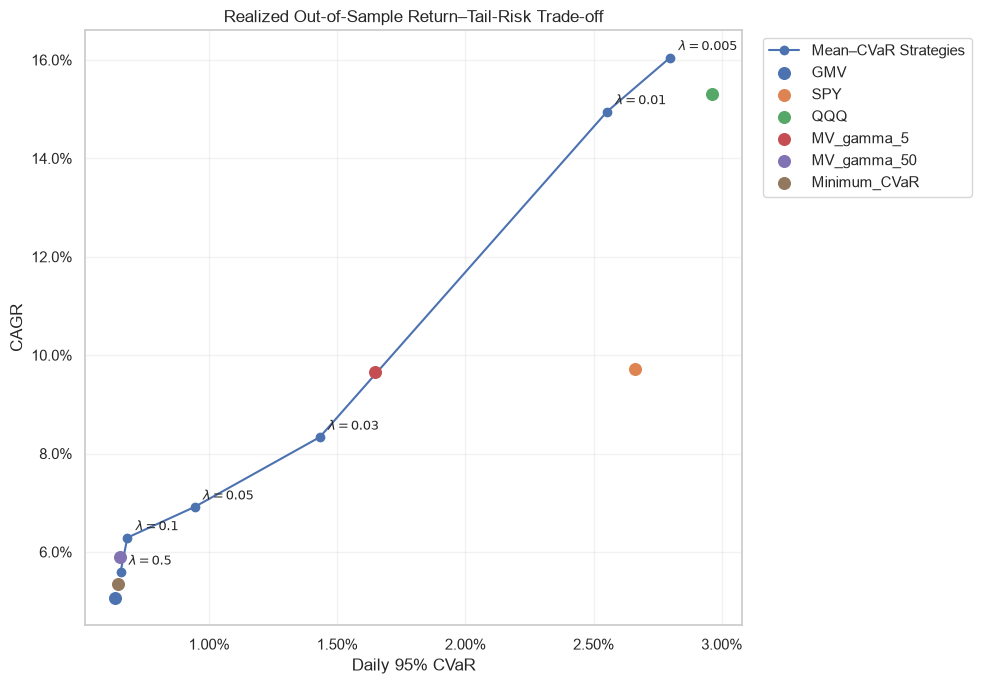

In [89]:
from matplotlib.ticker import PercentFormatter

mean_cvar_strategy_names = [
    strategy
    for strategy in cvar_performance_table.index
    if strategy.startswith("Mean_CVaR_lambda_")
]

frontier_points = (
    cvar_performance_table
    .loc[mean_cvar_strategy_names]
    .sort_values("Daily 95% CVaR")
)

fig, ax = plt.subplots(figsize=(10, 7))

ax.plot(
    frontier_points["Daily 95% CVaR"],
    frontier_points["CAGR"],
    marker="o",
    linewidth=1.5,
    label="Mean–CVaR Strategies",
)

for strategy, row in frontier_points.iterrows():
    penalty = strategy.replace(
        "Mean_CVaR_lambda_",
        "",
    )

    ax.annotate(
        rf"$\lambda={penalty}$",
        (
            row["Daily 95% CVaR"],
            row["CAGR"],
        ),
        xytext=(6, 5),
        textcoords="offset points",
        fontsize=9,
    )

comparison_strategies = [
    "GMV",
    "SPY",
    "QQQ",
    "MV_gamma_5",
    "MV_gamma_50",
    "Minimum_CVaR",
]

for strategy in comparison_strategies:
    ax.scatter(
        cvar_performance_table.loc[
            strategy,
            "Daily 95% CVaR",
        ],
        cvar_performance_table.loc[
            strategy,
            "CAGR",
        ],
        s=70,
        label=strategy,
        zorder=3,
    )

ax.set_title(
    "Realized Out-of-Sample Return–Tail-Risk Trade-off"
)
ax.set_xlabel("Daily 95% CVaR")
ax.set_ylabel("CAGR")

ax.xaxis.set_major_formatter(
    PercentFormatter(1.0)
)
ax.yaxis.set_major_formatter(
    PercentFormatter(1.0)
)

ax.grid(alpha=0.25)

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

In [94]:
selected_penalties = np.array([
    0.005,
    0.01,
    0.03,
    0.05,
    0.1,
    0.5,
])

frontier_penalties = np.unique(
    np.concatenate([
        np.logspace(
            -4,
            1,
            60,
        ),
        selected_penalties,
    ])
)

print(
    "Penalty range:",
    frontier_penalties.min(),
    "to",
    frontier_penalties.max(),
)

print(
    "Number of frontier points:",
    len(frontier_penalties),
)

Penalty range: 0.0001 to 10.0
Number of frontier points: 66


In [95]:
frontier_results = []

for cvar_penalty in frontier_penalties:
    solution = solve_mean_cvar(
        estimation_returns,
        cvar_penalty=cvar_penalty,
        confidence_level=CONFIDENCE_LEVEL,
    )

    optimized_returns = (
        estimation_returns
        @ solution["weights"]
    )

    _, estimated_cvar = (
        calculate_empirical_var_cvar(
            optimized_returns,
            confidence_level=CONFIDENCE_LEVEL,
        )
    )

    estimated_daily_return = (
        optimized_returns.mean()
    )

    frontier_results.append({
        "Lambda": cvar_penalty,
        "Estimated Daily Return":
            estimated_daily_return,
        "Estimated Annualized Return":
            estimated_daily_return
            * TRADING_DAYS,
        "Estimated Daily CVaR":
            estimated_cvar,
    })

mean_cvar_frontier = (
    pd.DataFrame(frontier_results)
    .sort_values(
        "Estimated Daily CVaR",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(mean_cvar_frontier.head())

,Lambda,Estimated Daily Return,Estimated Annualized Return,Estimated Daily CVaR
0,0.000322,0.000625,0.157398,0.037425
1,0.000392,0.000625,0.157398,0.037425
2,0.000579,0.000625,0.157398,0.037425
3,0.000704,0.000625,0.157398,0.037425
4,0.000855,0.000625,0.157398,0.037425


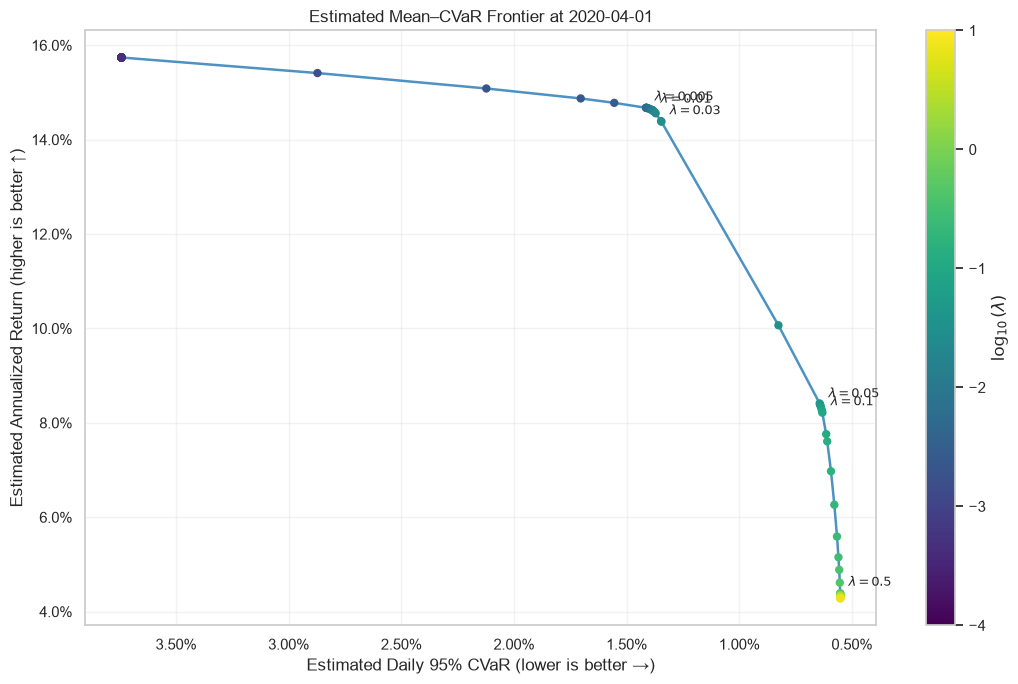

In [96]:
from matplotlib.ticker import PercentFormatter

fig, ax = plt.subplots(
    figsize=(11, 7)
)

ax.plot(
    mean_cvar_frontier[
        "Estimated Daily CVaR"
    ],
    mean_cvar_frontier[
        "Estimated Annualized Return"
    ],
    color="tab:blue",
    linewidth=1.8,
    alpha=0.8,
)

scatter = ax.scatter(
    mean_cvar_frontier[
        "Estimated Daily CVaR"
    ],
    mean_cvar_frontier[
        "Estimated Annualized Return"
    ],
    c=np.log10(
        mean_cvar_frontier["Lambda"]
    ),
    cmap="viridis",
    s=25,
    zorder=3,
)

for selected_penalty in selected_penalties:
    selected_point = (
        mean_cvar_frontier.loc[
            np.isclose(
                mean_cvar_frontier["Lambda"],
                selected_penalty,
            )
        ]
        .iloc[0]
    )

    ax.annotate(
        rf"$\lambda={selected_penalty:g}$",
        (
            selected_point[
                "Estimated Daily CVaR"
            ],
            selected_point[
                "Estimated Annualized Return"
            ],
        ),
        xytext=(6, 5),
        textcoords="offset points",
        fontsize=9,
    )

# Reverse the x-axis:
# lower CVaR appears farther to the right.
ax.invert_xaxis()

ax.set_title(
    "Estimated Mean–CVaR Frontier "
    f"at {formation_date.date()}"
)

ax.set_xlabel(
    "Estimated Daily 95% CVaR "
    "(lower is better →)"
)

ax.set_ylabel(
    "Estimated Annualized Return "
    "(higher is better ↑)"
)

ax.xaxis.set_major_formatter(
    PercentFormatter(1.0)
)

ax.yaxis.set_major_formatter(
    PercentFormatter(1.0)
)

colorbar = plt.colorbar(
    scatter,
    ax=ax,
)

colorbar.set_label(
    r"$\log_{10}(\lambda)$"
)

ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

### Estimated Mean–CVaR Frontier

The figure presents the estimated mean–CVaR frontier at a single formation
date. Each point represents a portfolio obtained by solving

$$
\max_w
\left\{
\hat{\mu}^{\top}w
-
\lambda\operatorname{CVaR}_{0.95}(-Rw)
\right\}
$$

for a different value of the tail-risk-aversion parameter $\lambda$. The
expected return and CVaR are estimated exclusively from the preceding
three-year window.

The horizontal axis is reversed so that lower CVaR appears farther to the
right, while higher expected return appears farther upward. Consequently,
movement toward the upper-right region is desirable in both dimensions.
However, no single portfolio simultaneously achieves the highest return and
lowest CVaR, so the appropriate location on the frontier depends on the
investor's tolerance for tail risk.

The frontier exhibits two visible elbow points and three broad regimes. At low
values of $\lambda$, the optimizer is return-seeking: substantial reductions in
CVaR can initially be obtained with relatively small reductions in expected
return. In the intermediate region, approximately around
$\lambda=0.03$ to $\lambda=0.05$ for this estimation window, the frontier bends
sharply and further reductions in tail risk require increasingly large
sacrifices in expected return. At higher values of $\lambda$, the portfolio
approaches the minimum-CVaR solution, producing diminishing improvements in
tail risk while expected return continues to decline.

The piecewise-linear shape is consistent with the linear-programming
formulation of empirical mean–CVaR optimization. As $\lambda$ changes, the
optimal allocation moves between different extreme solutions of the feasible
set.

The elbow points provide economically meaningful candidates for portfolio
selection, but they should not be interpreted as universally optimal values of
$\lambda$. The location and shape of the estimated frontier depend on the
historical estimation window and may change across formation dates. Moreover,
the figure describes an ex-ante estimated frontier rather than realized future
performance; the rolling out-of-sample backtest is required to evaluate whether
the estimated risk–return trade-off persists.
